# PREDICTING CUSTOMER LOYALTY BASED ON THE AMOUNT SPENT OVER TIME

## AUTHOR: UBANDIYA Najib Yusuf

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

Make pandas display all columns regardless of the total number of columns in the dataset.

In [17]:
pd.set_option('display.max_columns', None)

Read the dataset.

In [18]:
df = pd.read_csv('loyalty.csv')

## A quick EDA

In [19]:
df.head()

,customer_id,spend,first_month,items_in_first_month,region,loyalty_years,joining_month,promotion
0,1,132.68,15.3,5,Asia/Pacific,5-10,Nov,No
1,2,106.45,16.2,14,Asia/Pacific,0-1,Feb,Yes
2,3,123.16,25.26,7,Middle East/Africa,10+,Dec,Yes
3,4,130.60,24.74,8,Middle East/Africa,3-5,Apr,No
4,5,130.41,25.59,8,Middle East/Africa,3-5,Apr,Yes


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1246 entries, 0 to 1245
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           1246 non-null   int64  
 1   spend                 1246 non-null   float64
 2   first_month           1246 non-null   object 
 3   items_in_first_month  1246 non-null   int64  
 4   region                1246 non-null   object 
 5   loyalty_years         1246 non-null   object 
 6   joining_month         1121 non-null   object 
 7   promotion             1246 non-null   object 
dtypes: float64(1), int64(2), object(5)
memory usage: 78.0+ KB


In [21]:
df.describe()

,customer_id,spend,items_in_first_month
count,1246.000000,1246.000000,1246.000000
mean,623.500000,122.637119,9.418138
std,359.833526,9.975102,3.000288
min,1.000000,104.290000,5.000000
25%,312.250000,112.210000,7.000000
50%,623.500000,123.840000,9.000000
75%,934.750000,131.092500,13.000000
max,1246.000000,142.290000,15.000000


## Data Cleaning

Handle the first_month column

In [23]:
df['joining_month'].unique()

array(['Nov', 'Feb', 'Dec', 'Apr', 'May', nan, 'Jul', 'Oct', 'Jan', 'Sep',
       'Mar', 'Jun', 'Aug'], dtype=object)

Values in df['joining_month'] are in the wrong order

In [24]:
df['first_month'] = pd.to_numeric(df['first_month'], errors='coerce').ffill()
df['joining_month'] = df['joining_month'].astype('category').cat.reorder_categories(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], ordered=True
).ffill()

In [25]:
df['joining_month'].unique()

['Nov', 'Feb', 'Dec', 'Apr', 'May', ..., 'Jan', 'Sep', 'Mar', 'Jun', 'Aug']
Length: 12
Categories (12, object): ['Jan' < 'Feb' < 'Mar' < 'Apr' ... 'Sep' < 'Oct' < 'Nov' < 'Dec']

The joining_month column

In [26]:
month_map = {month: idx for idx, month in enumerate(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul',
                                                      'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], 1)}
df['joining_month'] = df['joining_month'].map(month_map).astype('int')

Loyalty_years column

In [27]:
df['loyalty_years'].unique()

array(['5-10', '0-1', '10+', '3-5', '1-3'], dtype=object)

Not numerical

In [28]:
year_map = {'0-1': 1, '1-3': 2, '3-5': 3, '5-10': 4, '10+': 5}
df['loyalty_years'] = df['loyalty_years'].map(year_map)

Promotion column

In [29]:
df['promotion'].unique()

array(['No', 'Yes', 'NO', 'YES'], dtype=object)

Inconsistent responses

In [31]:
df['promotion'] = df['promotion'].str.title()
promotion_map = {'Yes': 0, 'No': 1}
df['promotion'] = df['promotion'].map(promotion_map)

In [32]:
df['promotion'].unique()

array([1, 0], dtype=int64)

Region column

In [48]:
df['region'].unique()

array(['Asia/Pacific', 'Middle East/Africa', 'Europe', 'Americas'],
      dtype=object)

In [49]:
region_map = {'Asia/Pacific': 1, 'Middle East/Africa': 3, 'Europe': 2, 'Americas': 0}
df['region'] = df['region'].map(region_map)

df['region'].unique()

array([1, 3, 2, 0], dtype=int64)

Create new column the calculates the total amount spent by a customer

In [50]:
df['lifetime_spend'] = df['spend'] / (df['first_month'] + 1e-10)

## Visualisations

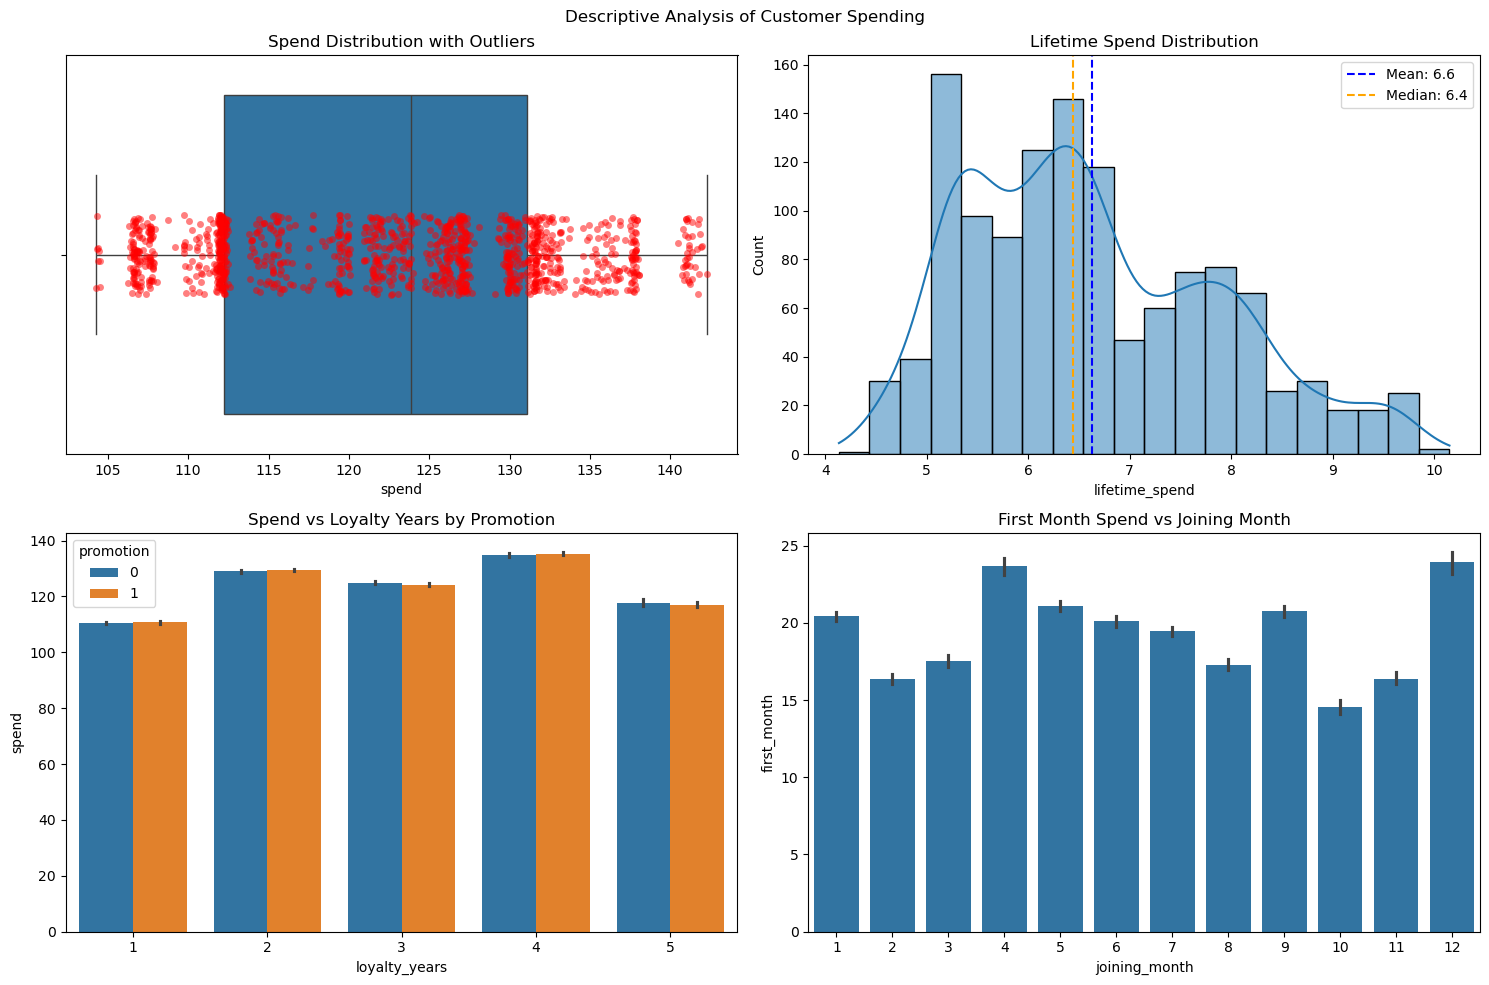

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(data=df, x='spend', ax=axes[0, 0], showfliers=False)
sns.stripplot(data=df, x='spend', ax=axes[0, 0], color="red", alpha=0.5)
axes[0, 0].set_title('Spend Distribution with Outliers')

sns.histplot(data=df, x='lifetime_spend', bins=20, kde=True, alpha=0.5, ax=axes[0, 1])
mean_val = df['lifetime_spend'].mean()
median_val = df['lifetime_spend'].median()
axes[0, 1].axvline(mean_val, color='blue', linestyle='--', label=f'Mean: {mean_val:.1f}')
axes[0, 1].axvline(median_val, color='orange', linestyle='--', label=f'Median: {median_val:.1f}')
axes[0, 1].legend()
axes[0, 1].set_title('Lifetime Spend Distribution')

sns.barplot(data=df, x='loyalty_years', y='spend', hue='promotion', ax=axes[1, 0])
axes[1, 0].set_title('Spend vs Loyalty Years by Promotion')

sns.barplot(data=df, x='joining_month', y='first_month', ax=axes[1, 1])
axes[1, 1].set_title('First Month Spend vs Joining Month')

fig.suptitle('Descriptive Analysis of Customer Spending')
plt.tight_layout()
plt.show()

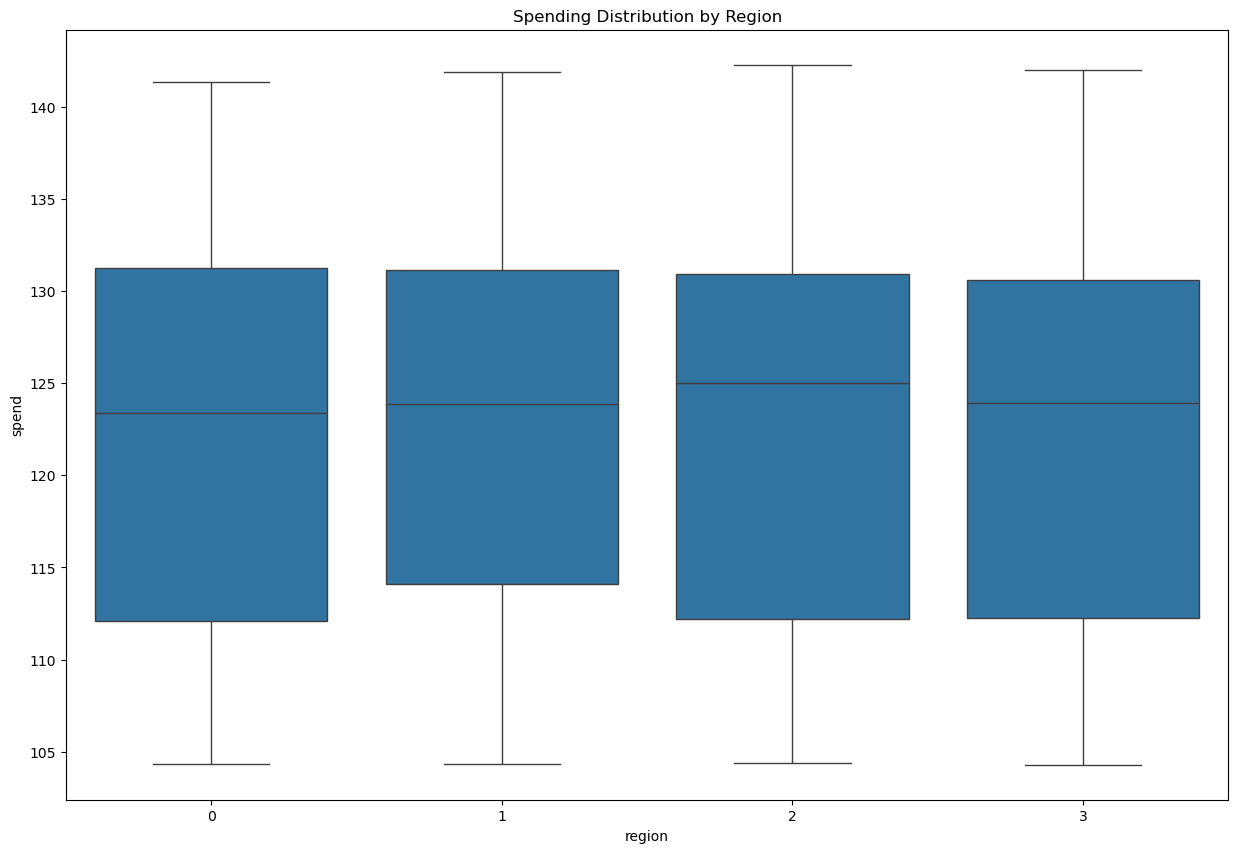

In [52]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=df, x='region', y='spend')
plt.title('Spending Distribution by Region')
plt.show()

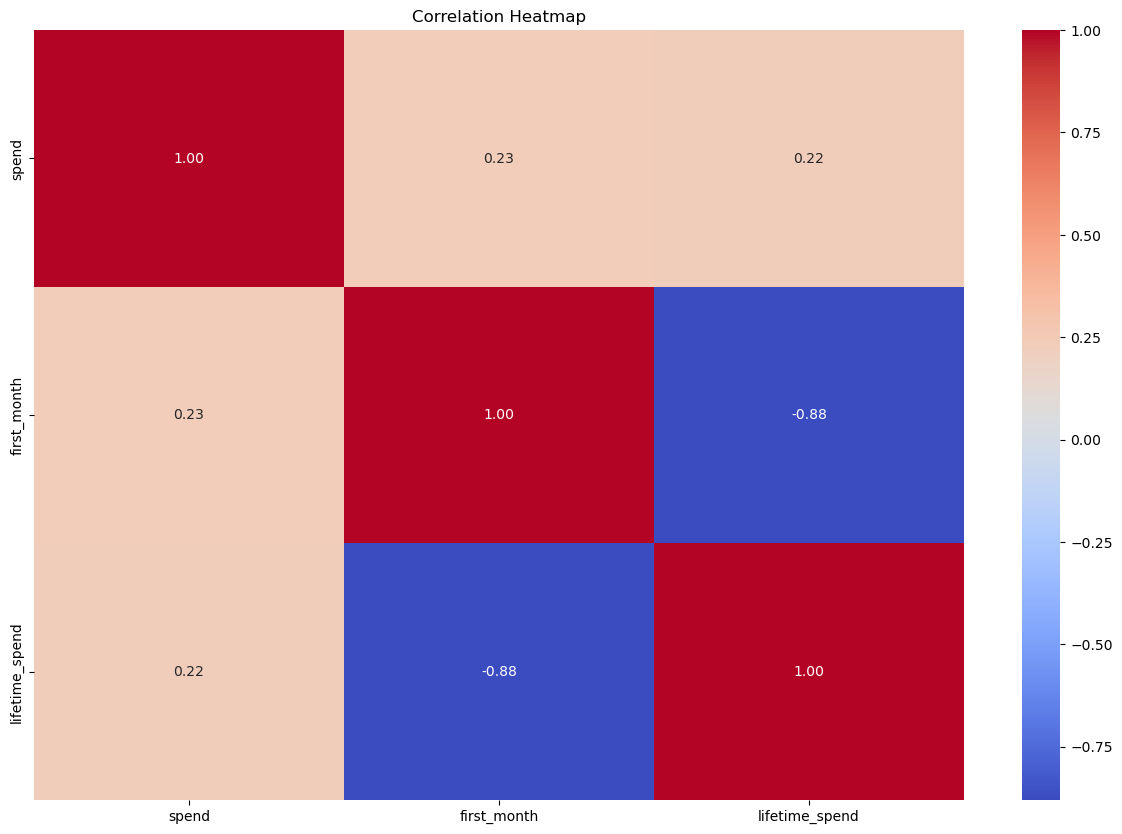

In [53]:
corr = df[['spend', 'first_month', 'lifetime_spend']].corr()

plt.figure(figsize=(15, 10))
sns.heatmap(corr, cmap='coolwarm', fmt='.2f', annot=True)
plt.title('Correlation Heatmap')
plt.show()

## Data preprocessing

In [54]:
X = df.drop(columns=['spend', 'customer_id'], axis=1)
y = df['spend']

In [55]:
X.shape

(1246, 7)

In [56]:
y.shape

(1246,)

Splitting the data for training and testing

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [58]:
print(f'X_train shape {X_train.shape}')

X_train shape (872, 7)


In [59]:
print(f'X_test shape {X_test.shape}')

X_test shape (374, 7)


In [60]:
scaler = StandardScaler().set_output(transform='pandas')

X_train, X_test = scaler.fit_transform(X_train), scaler.transform(X_test)

## Machine learning models

Random Forest Regressor and Decision Tree Regressor

In [61]:
rf = RandomForestRegressor(n_estimators=500, n_jobs=-1)
dt = DecisionTreeRegressor()

rf.fit(X_train, y_train)
dt.fit(X_train, y_train)

r_pred = rf.predict(X_test)
d_pred = dt.predict(X_test)

Evaluation

In [63]:
def analyse(model, true, prediction):
    print(model.__class__.__name__)
    print(f'MSE: {mean_squared_error(true, prediction)}')
    print(f'R2: {r2_score(true, prediction)}\n')

analyse(rf, y_test, r_pred)
analyse(dt, y_test, d_pred)

RandomForestRegressor
MSE: 1.4626855298845802
R2: 0.9836793855329233

DecisionTreeRegressor
MSE: 2.26391604278075
R2: 0.9747392722733983



## Feature importances using Random Forest

In [64]:
feature_importances = rf.feature_importances_
feature_names = X.columns

imporance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

In [66]:
imporance_df

,Feature,Importance
0,first_month,0.076386
1,items_in_first_month,0.003788
2,region,0.000266
3,loyalty_years,0.886114
4,joining_month,0.004786
5,promotion,0.000098
6,lifetime_spend,0.028562


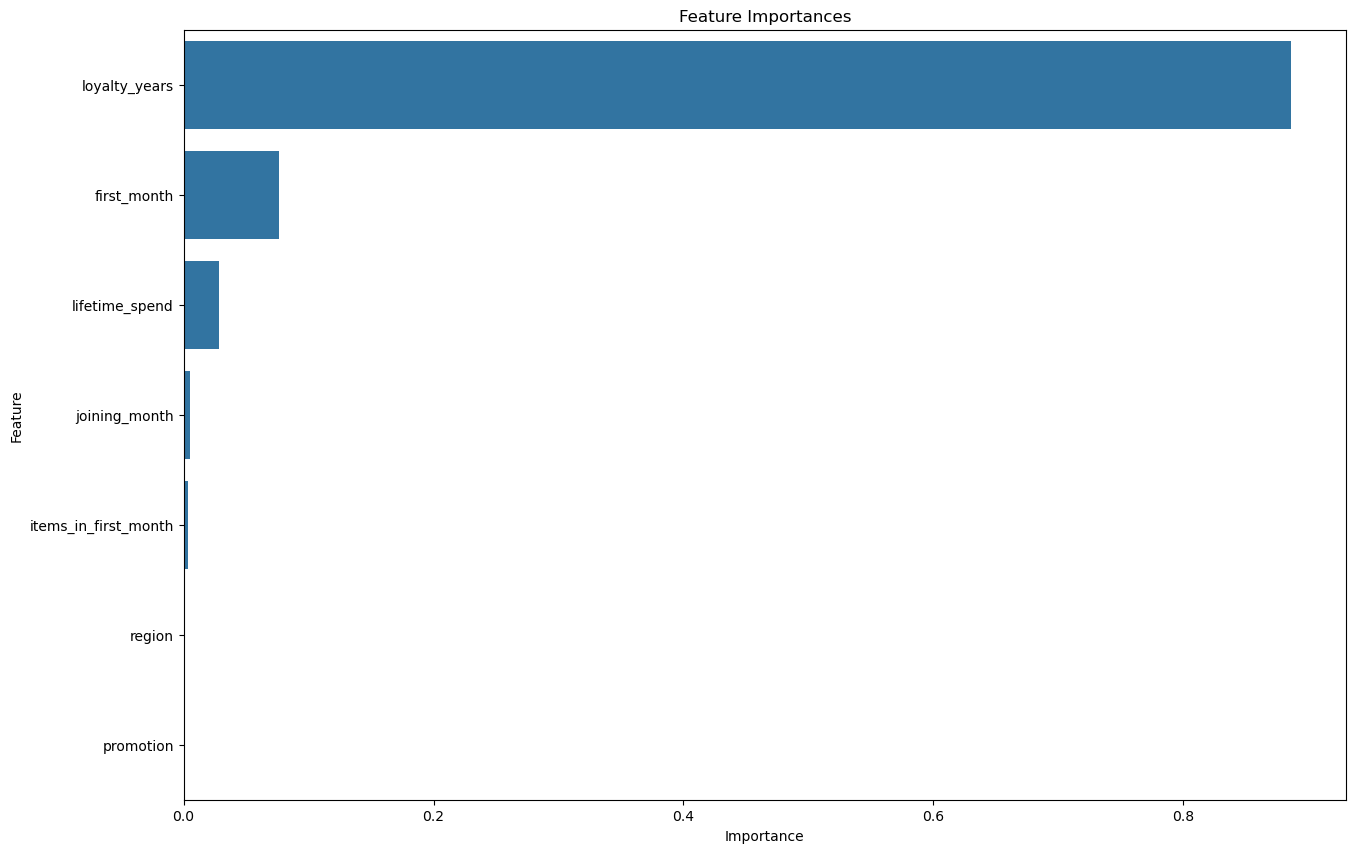

In [68]:
imporance_df = imporance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(15, 10))
sns.barplot(data=imporance_df, x='Importance', y='Feature')
plt.title('Feature Importances')
plt.show()


Error residuals

In [69]:
rf_residuals = y_test - r_pred
dt_residuals = y_test - d_pred

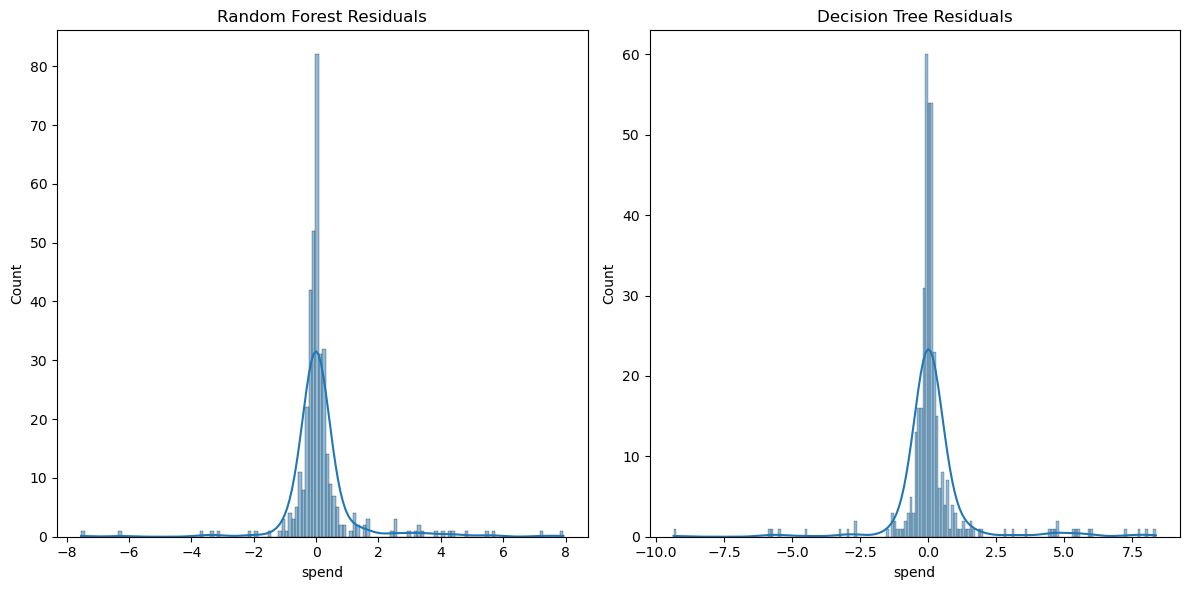

In [70]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(rf_residuals, kde=True)
plt.title('Random Forest Residuals')

plt.subplot(1, 2, 2)
sns.histplot(dt_residuals, kde=True)
plt.title('Decision Tree Residuals')

plt.tight_layout()
plt.show()